
#### step1: Load model

In [8]:
import torch
from torch import nn
from pathlib import Path

In [4]:
from pathlib import Path
current_path = Path.cwd()
dir_path = current_path / 'Data' / 'models'
# dir_path
model_path = dir_path / 'model0_state_dict.pth'
model_path

PosixPath('/home/aj/GenAI/deep_learning/CNN/Data/models/model0_state_dict.pth')

In [6]:
model0_state_dict = torch.load(f=model_path)
model0_state_dict

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [9]:
# but we do not have a definition of this model, only the weights are here
# let's define the model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        
    def forward(self,x:torch.tensor) -> torch.tensor:
        return self.weights * x + self.bias

In [12]:
model_0 = LinearRegressionModel()
model_0.state_dict()

OrderedDict([('weights', tensor([0.9549])), ('bias', tensor([0.3537]))])

In [13]:
# now we have both model definition and model state dict, both 
# Let's merge the model definition with weights to get the complete model
model_0.load_state_dict(state_dict=model0_state_dict)

<All keys matched successfully>

In [14]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

#### step2: make predictions

In [18]:
x_test = torch.tensor([[0.8000],[0.8200],[0.8400],[0.8600],[0.8800],[0.9000],[0.9200],[0.9400],[0.9600],[0.9800]])
y_test = torch.tensor([[0.8600],[0.8740],[0.8880],[0.9020],[0.9160],[0.9300],[0.9440],[0.9580],[0.9720],[0.9860]])

In [17]:
# put model in eval mode
model_0.eval()
with torch.inference_mode():
    y_pred = model_0(x_test)

y_pred

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [19]:
import matplotlib.pyplot as plt

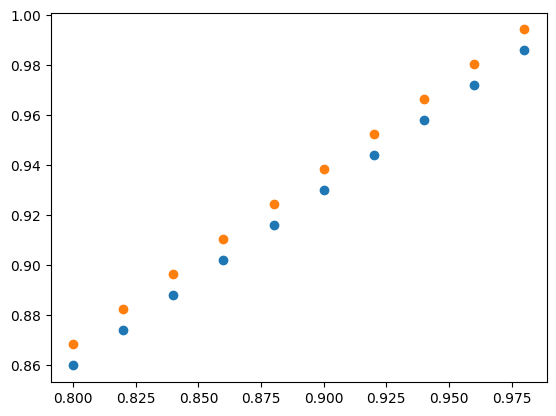

In [20]:
plt.scatter(x_test, y_test, label='test points')
plt.scatter(x_test, y_pred, label='predicted points')